# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one think or another (there can be multiple thinks as the options)

[Book version of this notebook](https://www.learnpytorch.io/02_pytorch_classification/)

[All other resources](https://github.com/mrdbourke/pytorch-deep-learning)

In [1]:
## 1. Make classification data and get it ready 

In [2]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn
import plotly.io as pio
# pio.renderers.default = 'vscode'  # lub 'vscode'
import plotly.express as px

In [3]:
# make 1000 samples

n_samples = 1000

# Create circles
X, y = make_circles(n_samples=n_samples, 
                    noise=0.03,
                    random_state=42)

In [4]:
X.shape

(1000, 2)

In [5]:
print(f'Forst 5 samples of X:\n{X[:5]}')
print(f'Forst 5 samples of y:\n{y[:5]}')

Forst 5 samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Forst 5 samples of y:
[1 1 1 1 0]


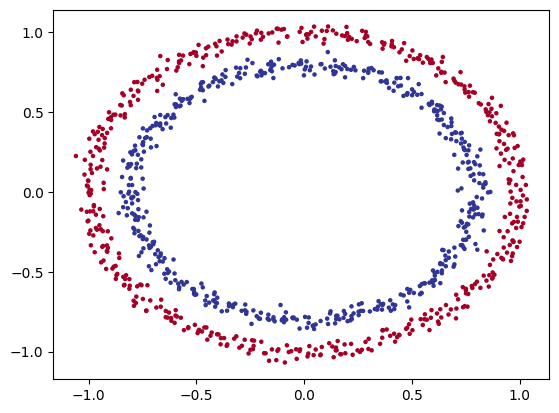

In [6]:
plt.scatter(X[:,0], 
            X[:,1], 
            c = y, 
            s = 5,
            cmap = plt.cm.RdYlBu) # c - labels


In [7]:
circles = pd.DataFrame({'X1': X[:, 0],
                        'X2': X[:, 1],
                        'label': y})

In [8]:
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


**Note**: The data we're wrkoing with is often referreed to as a toy dataset, a dataset is small enopugh to experiment but still sizeable enough to practice the fundamentals

In [9]:
X[0], y[0]
print(f'Values for one sample of X: {X[0]} and the same for y: {y[0]}')
print(f'Shapes for one sample of X: {X[0].shape} and the same for y: {y[0].shape}')

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [10]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [11]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [12]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

## 2. Building a model

Let's build a model to classify our blue and red dots. 

To do so, we want to:
1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Defining a loss function and optimizer 
4. Create a training and test loop

In [14]:
device = 'cude' if torch.cuda.is_available() else 'cpu'
device

'cpu'

Now we've setup device agnostic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shaped of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target `device`

[Fuuny toy](https://playground.tensorflow.org/)

In [15]:
X_train.shape

torch.Size([800, 2])

In [16]:
# 1. Construct a model that subclasses nn.Module

class CircleModelV0(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        # 2. Create 2 nn.Linear layers capable of handlikng the shapes of our data

        # self.layer_1 = nn.Linear(
        #     in_features= 2,
        #     out_features=5
        # )  # 2 features upscales into 5 hidden neurons

        # self.layer_2 = nn.Linear(
        #     in_features= 5,
        #     out_features= 1
        # )

        self.two_linear_layers = nn.Sequential(
            nn.Linear(
                in_features= 2, out_features= 32
            ),
            nn.ReLU(),
            nn.Linear(
                in_features= 32, out_features= 1
            )
        )

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # return self.layer_2(self.layer_1(x)) # x -> layer 1 -> layer 2
        return self.two_linear_layers(x)
    
# 4. Instantiate an isntance of our model class and send it to the target device
torch.manual_seed(42)
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [17]:
next(model_0.parameters()).device

device(type='cpu')

In [18]:
# # Lets replicate the model aboce using nn.Sequential()

# model_0 = nn.Sequential(
#     nn.Linear(
#         in_features= 2, out_features= 5
#     ),
#     nn.Linear(
#         in_features= 5, out_features= 1
#     )
# ).to(device)

In [19]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252],
                      [ 0.0667, -0.6984],
                      [ 0.6386, -0.6007],
                      [ 0.5459,  0.1177],
                      [-0.2296,  0.4370],
                      [ 0.1102,  0.5713],
                      [ 0.0773, -0.2230],
                      [ 0.1900, -0.1918],
                      [ 0.2976,  0.6313],
                      [ 0.4087, 

In [20]:
# Make predictions
with torch.inference_mode():
    unntrained_preds = model_0(X_test.to(device))
torch.round(unntrained_preds)[:10]

tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.]])

### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might want MAE or MSE.

For classification you might want binary cross entropy or categorical cross entropy.

As a reminder, the loss function measoures how wrong is our model.

And for optimizers, towo of the mos commong options are SGD and Adam

* for the loss function were goin to use `torch.nn.BCEWithLogitsLoss()`

In [21]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function built-in

optimizer = torch.optim.SGD(
    params = model_0.parameters(),
    lr = 0.01
)

In [22]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-0.3258, -0.0829],
                      [-0.2872,  0.4691],
                      [-0.5582, -0.3260],
                      [-0.1997, -0.4252],
                      [ 0.0667, -0.6984],
                      [ 0.6386, -0.6007],
                      [ 0.5459,  0.1177],
                      [-0.2296,  0.4370],
                      [ 0.1102,  0.5713],
                      [ 0.0773, -0.2230],
                      [ 0.1900, -0.1918],
                      [ 0.2976,  0.6313],
                      [ 0.4087, 

In [23]:
# Calculate accuracy
def accuracy_fn(y_pred, y_true):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc

## 3. Train model

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are goint to be raw **logits**

We can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification).

Then we can convert our model's prediction probabilities to **prediction labels** by either round them or taking the `argmax()`

In [24]:
# View first 5 outputs of the forward on the test data
with torch.inference_mode():
    y_logits = model_0(X_test)
y_logits

tensor([[-0.0885],
        [-0.0153],
        [-0.0271],
        [-0.0148],
        [-0.0497],
        [-0.1029],
        [-0.0568],
        [-0.0707],
        [-0.0823],
        [-0.0924],
        [-0.0647],
        [-0.0245],
        [-0.0497],
        [-0.1031],
        [-0.1032],
        [-0.0236],
        [-0.0779],
        [-0.0897],
        [-0.0960],
        [-0.0827],
        [-0.1020],
        [-0.0950],
        [-0.0664],
        [-0.0704],
        [-0.0546],
        [-0.0539],
        [-0.0695],
        [-0.0358],
        [-0.0827],
        [-0.0559],
        [-0.1199],
        [-0.0060],
        [-0.0181],
        [-0.0070],
        [-0.0509],
        [-0.0746],
        [-0.0463],
        [-0.0438],
        [-0.1048],
        [-0.0975],
        [-0.0140],
        [-0.0470],
        [-0.0669],
        [-0.0186],
        [-0.0337],
        [-0.0211],
        [-0.1216],
        [-0.0980],
        [-0.0710],
        [-0.0410],
        [-0.0553],
        [-0.1148],
        [-0.

In [25]:
min(y_logits)

tensor([-0.1271])

In [26]:
# use the sigmoid activation function on our model logits

y_pred_probs = torch.sigmoid(y_logits)

In [27]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

### 3.2 Building a training and testing loop

In [28]:
torch.manual_seed(42)

epochs = 1000

# Put data to target device

for epoch in range(epochs):
    ### Training
    model_0.train()

    # Forward
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn lgoits -> pred probbs -> pred labels

    # loss / accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCEWithLoss expects prediction probabilities as input
    #                y_train)
    loss = loss_fn(y_logits, y_train) # nn.BCEWithLogitsLoss expects raw logits as input
    acc = accuracy_fn(y_pred, y_train)

    # optimizer zero grad
    optimizer.zero_grad()

    # loss backward (backpropagation)
    loss.backward()

    # optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()

    if epoch % 10 == 0:
        with torch.inference_mode():
            test_logits = model_0(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss_test = loss_fn(test_logits, y_test)
            acc_test = accuracy_fn(test_pred, y_test)

        print(f'Epoch: {epoch}, loss train: {loss.item():.4f}, loss test: {loss_test.item():.4f}, test accuracy: {acc_test:.2f}')

    

Epoch: 0, loss train: 0.6891, loss test: 0.6894, test accuracy: 50.00
Epoch: 10, loss train: 0.6889, loss test: 0.6893, test accuracy: 50.00
Epoch: 20, loss train: 0.6888, loss test: 0.6892, test accuracy: 50.50
Epoch: 30, loss train: 0.6886, loss test: 0.6891, test accuracy: 53.00
Epoch: 40, loss train: 0.6885, loss test: 0.6889, test accuracy: 55.00
Epoch: 50, loss train: 0.6884, loss test: 0.6888, test accuracy: 55.50
Epoch: 60, loss train: 0.6882, loss test: 0.6887, test accuracy: 56.00
Epoch: 70, loss train: 0.6881, loss test: 0.6886, test accuracy: 54.50
Epoch: 80, loss train: 0.6880, loss test: 0.6885, test accuracy: 54.00
Epoch: 90, loss train: 0.6879, loss test: 0.6883, test accuracy: 54.50
Epoch: 100, loss train: 0.6877, loss test: 0.6882, test accuracy: 54.00
Epoch: 110, loss train: 0.6876, loss test: 0.6881, test accuracy: 54.00
Epoch: 120, loss train: 0.6875, loss test: 0.6880, test accuracy: 53.50
Epoch: 130, loss train: 0.6874, loss test: 0.6879, test accuracy: 53.50
Epo

## 4. Make predictions and valuate the model

`plot_decision_boundary()`

In [29]:
import requests

In [30]:
from pathlib import Path

# Download helper functions from repo if its no already downlaoded

if Path('helper_functions.py').is_file():
    print('helper_functions.py alredy exists')
else:
    print("Downloading helper_functions.py")
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

helper_functions.py alredy exists


In [31]:
from helper_functions import plot_decision_boundary, plot_predictions

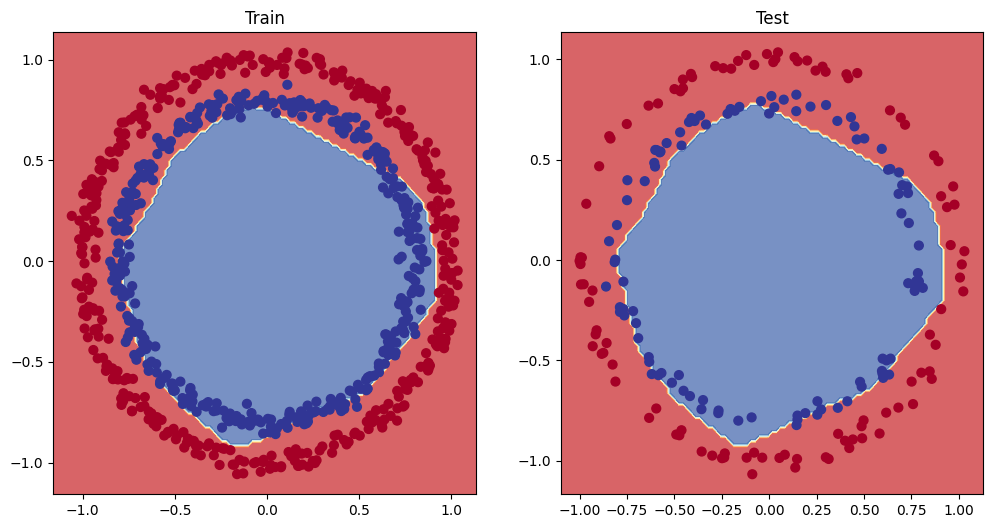

In [32]:
# plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model
* add more layers
* add mmore hidden units
* Fit for longer
* Changing the activation functions
* change the learning rate
* change the loss function 

In [33]:
class CircleModelV1(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=1),
        )

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.layers(x)
    
torch.manual_seed(42)
model_1 = CircleModelV1()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.01)  # przykładowe

In [34]:
torch.manual_seed(42)

epochs = 10

# Put data to target device

for epoch in range(epochs):
    ### Training
    model_1.train()

    # Forward
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn lgoits -> pred probbs -> pred labels

    # loss / accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCEWithLoss expects prediction probabilities as input
    #                y_train)
    loss = loss_fn(y_logits, y_train) # nn.BCEWithLogitsLoss expects raw logits as input
    acc = accuracy_fn(y_pred, y_train)

    # optimizer zero grad
    optimizer.zero_grad()

    # loss backward (backpropagation)
    loss.backward()

    # optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_1.eval()

    if epoch % 1 == 0:
        with torch.inference_mode():
            test_logits = model_1(X_test).squeeze()
            test_pred = torch.round(torch.sigmoid(test_logits))
            loss_test = loss_fn(test_logits, y_test)
            acc_test = accuracy_fn(test_pred, y_test)

        print(f'Epoch: {epoch}, loss train: {loss.item():.4f}, loss test: {loss_test.item():.4f}, test accuracy: {acc_test:.2f}')

    

Epoch: 0, loss train: 0.6918, loss test: 0.7084, test accuracy: 50.00
Epoch: 1, loss train: 0.7110, loss test: 0.7044, test accuracy: 50.00
Epoch: 2, loss train: 0.7026, loss test: 0.6899, test accuracy: 50.00
Epoch: 3, loss train: 0.6886, loss test: 0.6733, test accuracy: 68.00
Epoch: 4, loss train: 0.6726, loss test: 0.6598, test accuracy: 72.00
Epoch: 5, loss train: 0.6597, loss test: 0.6374, test accuracy: 88.50
Epoch: 6, loss train: 0.6372, loss test: 0.6033, test accuracy: 98.00
Epoch: 7, loss train: 0.6032, loss test: 0.5516, test accuracy: 99.50
Epoch: 8, loss train: 0.5516, loss test: 0.4835, test accuracy: 98.00
Epoch: 9, loss train: 0.4844, loss test: 0.3997, test accuracy: 98.50


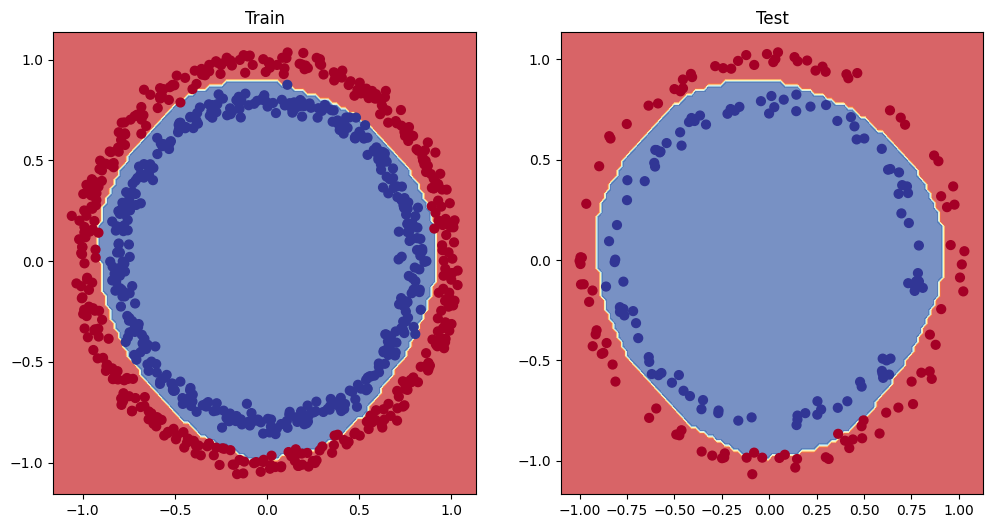

In [35]:
# plot decision boundary of the model

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [36]:
data = pd.DataFrame({'X1': X[:,0],
                     'X2': X[:,1]})
data

,X1,X2
0,0.754246,0.231481
1,-0.756159,0.153259
2,-0.815392,0.173282
3,-0.393731,0.692883
4,0.442208,-0.896723
...,...,...
995,0.244054,0.944125
996,-0.978655,-0.272373
997,-0.136900,-0.810012
998,0.670362,-0.767502


<Axes: xlabel='X1', ylabel='X2'>

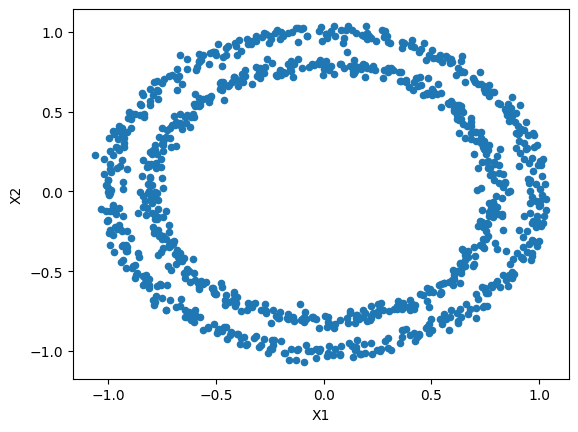

In [37]:
data.plot(kind='scatter', x = 'X1', y = 'X2')

In [38]:
pd.__version__

'2.2.3'

In [39]:
# pd.options.plotting.backend = "plotly"

<Axes: xlabel='X1', ylabel='X2'>

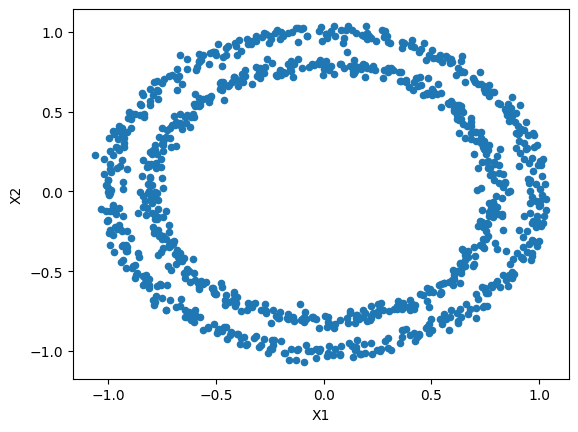

In [40]:
data.plot(kind='scatter', x = 'X1', y = 'X2')

In [41]:
import cufflinks as cf
cf.go_offline()


In [44]:
# px.bar_polar(data, x='X1', y='X2', title = 'Pod testa')

In [45]:
torch.arange(1,10,1),torch.arange(1,10,1).reshape(-1, 1),torch.arange(1,10,1).unsqueeze(dim=1)

(tensor([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 tensor([[1],
         [2],
         [3],
         [4],
         [5],
         [6],
         [7],
         [8],
         [9]]),
 tensor([[1],
         [2],
         [3],
         [4],
         [5],
         [6],
         [7],
         [8],
         [9]]))

## 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"

Or in machine learning terms, an infinite (but really it is finite) of linear and non-linear functions?

### 6.1 Recreating non-linear data (red and blue circles)

In [46]:
# make and plot data
X, y = make_circles(n_samples=1000,
                    noise=0.03,
                    random_state=42)
fig = px.scatter(
    pd.DataFrame({
        'X1': X[:,0],
        'X2': X[:,1],
        'y': y.astype("str")
    }),
    x='X1',
    y='X2',
    color='y',
    color_discrete_sequence=['red', 'blue']
)
fig.add_hline(y = 0.5)
fig.show()


In [47]:
df_3d = pd.DataFrame({
	'X1': X[:, 0],
	'X2': X[:, 1],
	'Pred': y
})

fig = px.scatter_3d(df_3d, x='X1', y='X2', z='Pred', color='Pred', title='3D Scatter: X1, X2, Prediction')
fig.show()

In [48]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 6.2 Building a model with non-linearity
* Linear
* Non-linear

In [49]:
from sklearn.datasets import make_blobs

In [129]:
X, y = make_blobs(n_samples=1000, n_features=3, centers=4, cluster_std= 1.5)

In [130]:
pd_X = pd.DataFrame({
    'X1': X[:,0],
    'X2': X[:,1],
    'X3': X[:,2],
    'y': y
})

In [98]:
import numpy as np

fig = px.scatter_3d(pd_X, x='X1', y='X2', z='X3', color='y')
fig.update_traces(marker=dict(size=3))  # Set marker size to 3 (smaller)
fig.show()

In [ ]:
X = torch.from_numpy(X).type(torch.float).to(device)
y = torch.from_numpy(y).type(torch.long).to(device) # z jakiegos powodu musi byc long, a nie float, hgw

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [139]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=9):
        """
        Initializes multi-class classification model
        
        Args:
            input_features (int): Number of input features to the model
            output_features (int) Number of outputs features (number of output classes)
            hidden_units (int): Number of hidden units between layers, defaut 8
        Returns:

        Example:


        """
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.network(x)
    

model_4 = BlobModel(input_features = 3,
                    output_features = 4,
                    hidden_units=64).to(device)

In [140]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_4.parameters(),
                             lr = 0.01)

In [141]:
model_4.eval()
with torch.inference_mode():
    y_pred = model_4(X_test)

y_pred_outs = torch.softmax(y_pred, dim=1)
y_pred_outs

tensor([[0.1744, 0.2116, 0.3093, 0.3047],
        [0.3286, 0.1472, 0.3483, 0.1759],
        [0.1078, 0.1479, 0.4180, 0.3263],
        [0.0905, 0.1604, 0.4093, 0.3398],
        [0.1213, 0.1066, 0.4538, 0.3183],
        [0.1346, 0.1358, 0.4248, 0.3048],
        [0.1419, 0.1378, 0.4379, 0.2824],
        [0.3102, 0.1607, 0.3368, 0.1923],
        [0.1094, 0.1596, 0.4014, 0.3296],
        [0.1701, 0.1554, 0.3942, 0.2803],
        [0.3236, 0.1639, 0.3238, 0.1887],
        [0.2931, 0.1588, 0.3618, 0.1863],
        [0.1168, 0.1078, 0.4503, 0.3251],
        [0.2927, 0.1522, 0.3685, 0.1866],
        [0.1130, 0.1076, 0.4509, 0.3285],
        [0.1770, 0.1657, 0.2698, 0.3875],
        [0.2833, 0.1727, 0.3477, 0.1963],
        [0.1853, 0.1398, 0.2501, 0.4248],
        [0.1575, 0.1853, 0.3688, 0.2884],
        [0.1245, 0.1271, 0.4158, 0.3327],
        [0.1035, 0.1294, 0.4187, 0.3484],
        [0.3176, 0.1553, 0.3431, 0.1840],
        [0.3115, 0.1497, 0.3564, 0.1824],
        [0.1877, 0.1524, 0.2771, 0

In [142]:
y_pred_labels = torch.argmax(y_pred_outs, dim=1)
y_pred_labels

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3,
        2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 2, 2, 3, 3, 2, 3, 2, 2, 0, 2, 2,
        0, 2, 3, 3, 3, 2, 2, 2, 2, 2, 0, 3, 2, 3, 3, 2, 2, 2, 2, 0, 2, 2, 3, 3,
        2, 2, 3, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 0, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 3, 3, 3, 2, 2,
        2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3,
        2, 3, 2, 0, 2, 2, 3, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2,
        3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 0, 2, 2, 2, 0,
        2, 3, 2, 2, 2, 2, 2, 2])

In [143]:
y_test.long()

tensor([3, 0, 1, 1, 2, 1, 2, 0, 1, 1, 0, 0, 2, 0, 1, 3, 0, 3, 1, 1, 1, 0, 0, 3,
        2, 1, 3, 0, 1, 0, 0, 1, 0, 3, 1, 3, 2, 1, 0, 3, 3, 2, 3, 2, 1, 0, 3, 0,
        0, 2, 3, 3, 3, 0, 2, 2, 1, 3, 0, 3, 3, 3, 3, 2, 2, 2, 2, 0, 1, 0, 3, 3,
        2, 2, 3, 0, 0, 1, 0, 3, 3, 0, 0, 1, 1, 1, 3, 2, 1, 2, 3, 3, 1, 2, 0, 0,
        0, 0, 0, 2, 2, 1, 1, 1, 3, 0, 1, 0, 2, 3, 1, 1, 2, 2, 3, 3, 3, 3, 0, 1,
        3, 0, 0, 2, 0, 2, 1, 1, 1, 2, 1, 1, 1, 0, 2, 0, 2, 2, 1, 1, 3, 0, 2, 3,
        1, 3, 1, 0, 1, 0, 3, 2, 0, 2, 2, 3, 0, 3, 3, 2, 2, 0, 0, 1, 0, 3, 0, 1,
        3, 2, 0, 2, 1, 0, 3, 0, 1, 0, 0, 0, 1, 3, 3, 0, 2, 1, 2, 0, 1, 2, 1, 0,
        0, 3, 1, 0, 1, 1, 2, 2])

In [144]:
epochs = 1000
for epoch in range(epochs):
    model_4.train()
    y_pred_logits = model_4(X_train)
    train_loss = loss_fn(y_pred_logits, y_train)  # CrossEntropyLoss expects class indices as target
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_4.eval()
    with torch.inference_mode():
        y_pred_logits = model_4(X_test)
        test_loss = loss_fn(y_pred_logits, y_test)
        y_pred_probs = torch.softmax(y_pred_logits, dim=1).argmax(dim=1)
        acc = accuracy_fn(y_pred_probs, y_test)
        
        if epoch % 100 == 0:
            print(f'Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {acc:.2f}')

Train loss: 1.2133 | Test loss: 0.5886 | Test accuracy: 74.00
Train loss: 0.0899 | Test loss: 0.1200 | Test accuracy: 93.50
Train loss: 0.0789 | Test loss: 0.1260 | Test accuracy: 93.50
Train loss: 0.0749 | Test loss: 0.1327 | Test accuracy: 92.50
Train loss: 0.0709 | Test loss: 0.1465 | Test accuracy: 93.00
Train loss: 0.0671 | Test loss: 0.1472 | Test accuracy: 92.50
Train loss: 0.0634 | Test loss: 0.1394 | Test accuracy: 91.50
Train loss: 0.0605 | Test loss: 0.1560 | Test accuracy: 92.00
Train loss: 0.0592 | Test loss: 0.1720 | Test accuracy: 92.00
Train loss: 0.0529 | Test loss: 0.1741 | Test accuracy: 92.00
